In [2]:
!pip install -U langchain langgraph langsmith
!pip install -U langchain-classic langchain-community langchain-core langchain-text-splitters
!pip install -U langchain-astradb langchain-aws langchain-chroma
!pip install -U azure-ai-documentintelligence openai sentence-transformers openpyxl pypdf PyPDF2
!pip install -U langchain-google-genai langchain-groq langchain-huggingface langchain-neo4j langchain-nvidia-ai-endpoints langchain-ollama langchain-openai

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
import os
from google.colab import userdata
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGCHAIN_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = userdata.get('LANGCHAIN_PROJECT')

In [5]:
from langchain_openai import AzureChatOpenAI

In [6]:
llm = AzureChatOpenAI(
    azure_endpoint=userdata.get("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=userdata.get("AZURE_OPENAI_LLM_MODEL"),
    api_version="2025-04-01-preview",
    api_key=userdata.get("AZURE_OPENAI_API_KEY"),
    max_tokens=4096,
)
llm

AzureChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x7c268c317f20>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7c268c317d40>, root_client=<openai.lib.azure.AzureOpenAI object at 0x7c268d8446e0>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x7c26c98c4560>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=4096, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://pfs-2-namit-resource.cognitiveservices.azure.com/', deployment_name='gpt-5.2-chat', openai_api_version='2025-04-01-preview', openai_api_type='azure')

In [12]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [13]:
class State(TypedDict):
  messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)
graph_builder

In [14]:
def chatbot(state: State):
  return {"messages": llm.invoke(state['messages'])}

In [15]:
graph_builder.add_node("chatbot", chatbot)
graph_builder

In [16]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

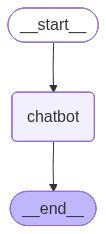

In [17]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass


In [19]:
while True:
  user_input = input("User (Enter any input or type 'quit' / q to exit): ")
  if user_input.lower().strip() in ["quit", "q"]:
    print("Good Bye!")
    break
  for event in graph.stream({"messages": ("user", user_input)}):
    for value in event.values():
      print("Assistant: ", value["messages"].content)

User (Enter any input or type 'quit' / q to exit): What is the diff between gpt 5.2 and 5.2? In 5 bullet points
Assistant:  I think there’s a typo or ambiguity in your question 🙂

Right now, **“gpt‑5.2” vs “5.2”** are the same thing unless you meant one of the following:

1. **GPT‑5.2 vs GPT‑4.2**
2. **GPT‑5.2 vs o5.2 (the reasoning‑focused o‑series)**
3. **GPT‑5.2 vs an earlier GPT‑5.x version (like 5.1)**

Could you confirm which comparison you want?

If you reply with something like **“GPT‑5.2 vs o5.2”**, I’ll give you the **5 bullet‑point diff** immediately.
User (Enter any input or type 'quit' / q to exit): I meant 5.2 and 4o
Assistant:  Got it — you mean **GPT‑5.2 and GPT‑4o**.

What would you like to do with them?
- Compare capabilities (reasoning, speed, multimodality, etc.)
- Decide which is better for a specific task
- Clarify naming / differences
- Something else?

Tell me the context and I’ll tailor the answer.
User (Enter any input or type 'quit' / q to exit): just a vs ta